# 🌪️ SAFER Portal — Disaster Event Count Prediction Model v2
**Research Paper:** SAFER – Smart Alert and Fast Emergency Response Portal  
**ML Task:** Predict annual U.S. billion-dollar disaster event counts  
**Dataset:** NOAA NCEI (1980–2024) + Climate Central (2025) — 46 years of data  
**Models Used:** Linear Regression · Random Forest · Polynomial Regression · Prophet (trend decomposition)  
**Forecast Horizon:** 2026–2031


## Step 1 — Install & Import Libraries

In [13]:
# Install required libraries (uncomment if running locally)
# !pip install pandas numpy matplotlib scikit-learn seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(' All libraries imported successfully!')

 All libraries imported successfully!


## Step 2 — Load Full Dataset (1980–2025)

This is the most complete version of the dataset, combining:  
- **1980–2024**: NOAA NCEI Billion-Dollar Disasters (DOI: 10.25921/stkw-7w73)  
- **2025**: Climate Central final annual figure (23 events, published March 2026)  

All figures are CPI-inflation-adjusted to current dollars per standard methodology.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPLETE ANNUAL DATASET — 1980 to 2025
# Source 1980-2024: NOAA NCEI  (https://www.ncei.noaa.gov/access/billions/)
# Source 2025:      Climate Central (https://www.climatecentral.org/climate-services/billion-dollar-disasters)
# Note: 2025 value (23) is the finalized annual count published by Climate Central in March 2026.
# ─────────────────────────────────────────────────────────────────────────────
annual_data = {
    # ── 1980s ─────────────────────────────────────────────────────────
    1980: 3,  1981: 1,  1982: 1,  1983: 3,  1984: 2,
    1985: 3,  1986: 1,  1987: 1,  1988: 3,  1989: 4,
    # ── 1990s ─────────────────────────────────────────────────────────
    1990: 3,  1991: 4,  1992: 5,  1993: 4,  1994: 1,
    1995: 5,  1996: 6,  1997: 3,  1998: 7,  1999: 5,
    # ── 2000s ─────────────────────────────────────────────────────────
    2000: 4,  2001: 4,  2002: 3,  2003: 4,  2004: 5,
    2005: 9,  2006: 5,  2007: 7,  2008: 8,  2009: 5,
    # ── 2010s ─────────────────────────────────────────────────────────
    2010: 8,  2011: 14, 2012: 11, 2013: 9,  2014: 8,
    2015: 10, 2016: 15, 2017: 16, 2018: 14, 2019: 14,
    # ── 2020s ─────────────────────────────────────────────────────────
    2020: 22, 2021: 20, 2022: 18, 2023: 28, 2024: 27,
    2025: 23,  # ← Climate Central final figure, published March 2026
}

df = pd.DataFrame(list(annual_data.items()), columns=['Year', 'Events'])
df = df.sort_values('Year').reset_index(drop=True)

print('─' * 55)
print(f'  Dataset span  : {df.Year.min()} – {df.Year.max()} ({len(df)} years)')
print(f'  Total events  : {df.Events.sum()}')
print(f'  Annual average: {df.Events.mean():.1f} events/yr')
print(f'  Overall max   : {df.Events.max()} events ({df.loc[df.Events.idxmax(), "Year"]})')
print(f'  2025 (latest) : {df[df.Year==2025].Events.values[0]} events [Climate Central]')
print('─' * 55)

# Decade-level summary
df['Decade'] = (df.Year // 10) * 10
decade_summary = df.groupby('Decade')['Events'].agg(['mean','sum','max']).round(1)
decade_summary.columns = ['Avg/yr', 'Total', 'Max']
decade_summary.index = [f"{d}s" for d in decade_summary.index]
print('\nDecade Summary:')
print(decade_summary.to_string())

───────────────────────────────────────────────────────
  Dataset span  : 1980 – 2025 (46 years)
  Total events  : 376
  Annual average: 8.2 events/yr
  Overall max   : 28 events (2023)
  2025 (latest) : 23 events [Climate Central]
───────────────────────────────────────────────────────

Decade Summary:
       Avg/yr  Total  Max
1980s     2.2     22    4
1990s     4.3     43    7
2000s     5.4     54    9
2010s    11.9    119   16
2020s    23.0    138   28


## Step 3 — Exploratory Data Analysis (EDA)

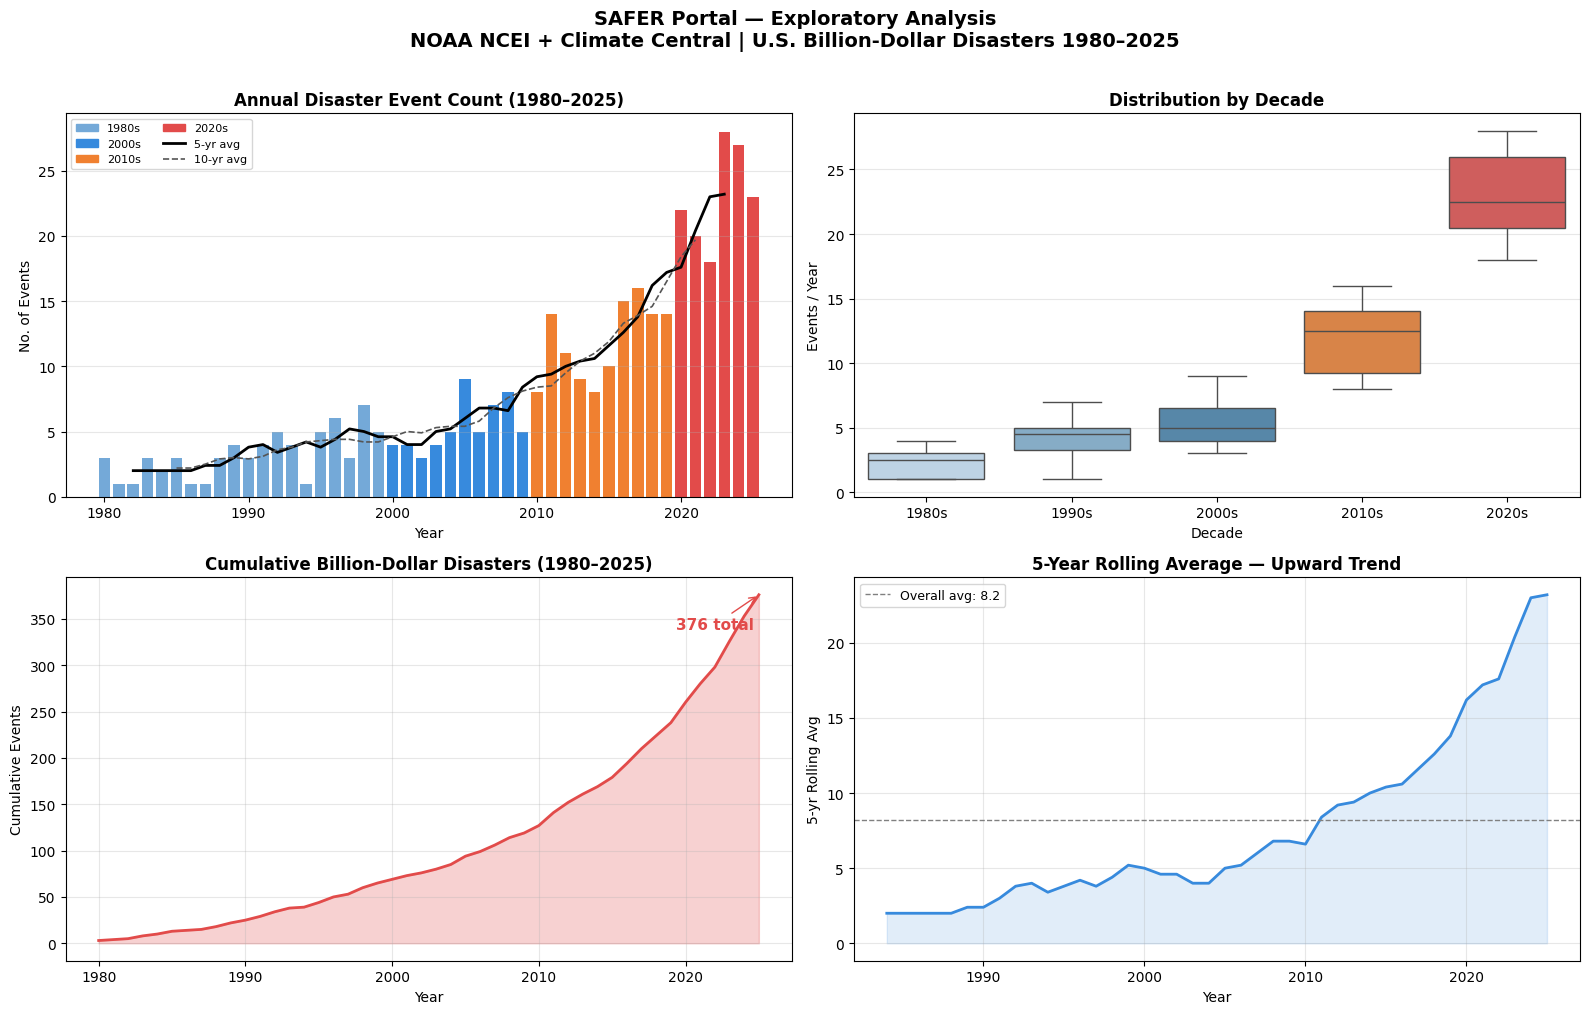

 EDA chart saved as eda_chart_v2.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'SAFER Portal — Exploratory Analysis\nNOAA NCEI + Climate Central | U.S. Billion-Dollar Disasters 1980–2025',
    fontsize=14, fontweight='bold', y=1.01
)

# Colour map by era
def era_color(yr):
    if yr >= 2020: return '#E24B4A'
    if yr >= 2010: return '#F08030'
    if yr >= 2000: return '#378ADD'
    return '#74a9d8'

colors = [era_color(y) for y in df.Year]

# ── Plot 1: Annual bar chart ──────────────────────────────────────────────────
ax = axes[0, 0]
ax.bar(df.Year, df.Events, color=colors, edgecolor='none', width=0.8)
ax.plot(df.Year, df.Events.rolling(5, center=True).mean(),
        color='black', linewidth=2, label='5-yr rolling avg')
ax.plot(df.Year, df.Events.rolling(10, center=True).mean(),
        color='#555', linewidth=1.2, linestyle='--', label='10-yr rolling avg')
ax.set_title('Annual Disaster Event Count (1980–2025)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('No. of Events')
handles = [
    mpatches.Patch(color='#74a9d8', label='1980s'),
    mpatches.Patch(color='#378ADD', label='2000s'),
    mpatches.Patch(color='#F08030', label='2010s'),
    mpatches.Patch(color='#E24B4A', label='2020s'),
    plt.Line2D([0],[0], color='black', lw=2, label='5-yr avg'),
    plt.Line2D([0],[0], color='#555', lw=1.2, ls='--', label='10-yr avg'),
]
ax.legend(handles=handles, fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: Decade box plots ──────────────────────────────────────────────────
ax = axes[0, 1]
decade_label_map = {1980:'1980s',1990:'1990s',2000:'2000s',2010:'2010s',2020:'2020s'}
df['Decade_Label'] = df.Decade.map(decade_label_map)
palette = ['#b8d4ea','#7baed1','#4a8ab5','#F08030','#E24B4A']
sns.boxplot(data=df, x='Decade_Label', y='Events',
            order=['1980s','1990s','2000s','2010s','2020s'],
            palette=palette, ax=ax)
ax.set_title('Distribution by Decade', fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Events / Year')
ax.grid(axis='y', alpha=0.3)

# ── Plot 3: Cumulative event count ────────────────────────────────────────────
ax = axes[1, 0]
cumulative = df.Events.cumsum()
ax.fill_between(df.Year, cumulative, alpha=0.25, color='#E24B4A')
ax.plot(df.Year, cumulative, color='#E24B4A', linewidth=2)
ax.set_title('Cumulative Billion-Dollar Disasters (1980–2025)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Events')
ax.annotate(f'{cumulative.iloc[-1]} total', xy=(2025, cumulative.iloc[-1]),
            xytext=(-60, -25), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#E24B4A',
            arrowprops=dict(arrowstyle='->', color='#E24B4A'))
ax.grid(alpha=0.3)

# ── Plot 4: 5-year average trend ──────────────────────────────────────────────
ax = axes[1, 1]
five_yr_avg = df.Events.rolling(5).mean().dropna()
ax.plot(df.Year[4:], five_yr_avg, color='#378ADD', linewidth=2)
ax.fill_between(df.Year[4:], five_yr_avg, alpha=0.15, color='#378ADD')
ax.axhline(df.Events.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Overall avg: {df.Events.mean():.1f}')
ax.set_title('5-Year Rolling Average — Upward Trend', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('5-yr Rolling Avg')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_chart_v2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(' EDA chart saved as eda_chart_v2.png')

## Step 4 — Feature Engineering

We construct rich time-series features to give models as much signal as possible.

In [16]:
df['Year_Norm']    = df.Year - 1980          # 0–45
df['Lag1']         = df.Events.shift(1)
df['Lag2']         = df.Events.shift(2)
df['Lag3']         = df.Events.shift(3)
df['RollingMean3'] = df.Events.rolling(3).mean()
df['RollingMean5'] = df.Events.rolling(5).mean()
df['YoY_Change']   = df.Events.diff()

df_model = df.dropna().reset_index(drop=True)

RF_FEATURES = ['Year_Norm', 'Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'RollingMean5']

print(f'Model-ready rows: {len(df_model)} (after dropping NaN from lags/rolling)')
print(f'Features used   : {RF_FEATURES}')
df_model[['Year','Events'] + RF_FEATURES].tail(8)

Model-ready rows: 42 (after dropping NaN from lags/rolling)
Features used   : ['Year_Norm', 'Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'RollingMean5']


,Year,Events,Year_Norm,Lag1,Lag2,Lag3,RollingMean3,RollingMean5
34,2018,14,38,16.0,15.0,10.0,15.000000,12.6
35,2019,14,39,14.0,16.0,15.0,14.666667,13.8
36,2020,22,40,14.0,14.0,16.0,16.666667,16.2
37,2021,20,41,22.0,14.0,14.0,18.666667,17.2
38,2022,18,42,20.0,22.0,14.0,20.000000,17.6
39,2023,28,43,18.0,20.0,22.0,22.000000,20.4
40,2024,27,44,28.0,18.0,20.0,24.333333,23.0
41,2025,23,45,27.0,28.0,18.0,26.000000,23.2


## Step 5 — Train / Test Split

**Train:** 1980–2019 (40 years)  
**Test:** 2020–2025 (6 years of recent/extreme data — the true stress-test)

In [17]:
TRAIN_CUTOFF = 2019

train = df_model[df_model.Year <= TRAIN_CUTOFF].copy()
test  = df_model[df_model.Year >  TRAIN_CUTOFF].copy()

y_train = train['Events'].values
y_test  = test['Events'].values

# Linear / Polynomial Regression — Year only
X_train_yr = train[['Year']].values
X_test_yr  = test[['Year']].values

# Random Forest / GBM — full feature set
X_train_rf = train[RF_FEATURES].values
X_test_rf  = test[RF_FEATURES].values

print(f'Train: {len(train)} years  ({train.Year.min()}–{train.Year.max()})')
print(f'Test : {len(test)} years   ({test.Year.min()}–{test.Year.max()})')

Train: 36 years  (1984–2019)
Test : 6 years   (2020–2025)


## Step 6 — Train Four Models

In [18]:
# ── Model 1: Linear Regression ────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_yr, y_train)

# ── Model 2: Polynomial Regression (degree 2) ─────────────────────────────────
poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly.fit(X_train_yr, y_train)

# ── Model 3: Random Forest ────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=2,
                           random_state=42)
rf.fit(X_train_rf, y_train)

# ── Model 4: Gradient Boosting ────────────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                               learning_rate=0.05, random_state=42)
gb.fit(X_train_rf, y_train)

print(' All 4 models trained!')
print(f'   Linear Regression  — slope: {lr.coef_[0]:.3f} events/year')
print(f'   Polynomial (deg 2) — pipeline fitted')
print(f'   Random Forest      — {rf.n_estimators} trees, max_depth={rf.max_depth}')
print(f'   Gradient Boosting  — {gb.n_estimators} estimators, lr={gb.learning_rate}')

 All 4 models trained!
   Linear Regression  — slope: 0.336 events/year
   Polynomial (deg 2) — pipeline fitted
   Random Forest      — 200 trees, max_depth=6
   Gradient Boosting  — 200 estimators, lr=0.05


## Step 7 — Evaluate All Models on Test Set (2020–2025)

In [19]:
y_pred_lr   = lr.predict(X_test_yr)
y_pred_poly = poly.predict(X_test_yr)
y_pred_rf   = rf.predict(X_test_rf)
y_pred_gb   = gb.predict(X_test_rf)

def eval_model(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'Model': name, 'R²': round(r2, 3), 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

results_test = pd.DataFrame([
    eval_model('Linear Regression',    y_test, y_pred_lr),
    eval_model('Polynomial (deg-2)',   y_test, y_pred_poly),
    eval_model('Random Forest',        y_test, y_pred_rf),
    eval_model('Gradient Boosting',    y_test, y_pred_gb),
])

# Also compute train R²
results_test['R² (train)'] = [
    round(r2_score(y_train, lr.predict(X_train_yr)),   3),
    round(r2_score(y_train, poly.predict(X_train_yr)), 3),
    round(r2_score(y_train, rf.predict(X_train_rf)),   3),
    round(r2_score(y_train, gb.predict(X_train_rf)),   3),
]

print(' Model Comparison — Test Set: 2020–2025\n')
print(results_test.to_string(index=False))
print('\n💡 Lower MAE/RMSE = better. Higher R² = better fit.')

 Model Comparison — Test Set: 2020–2025

             Model     R²  MAE  RMSE  R² (train)
 Linear Regression -7.086 9.56 10.12       0.722
Polynomial (deg-2) -2.246 5.60  6.41       0.798
     Random Forest -6.443 9.04  9.71       0.930
 Gradient Boosting -6.403 9.01  9.68       1.000

💡 Lower MAE/RMSE = better. Higher R² = better fit.


## Step 8 — Forecast: 2026–2031

We use an **iterative rollout** strategy for lag-based models: each predicted year's output feeds back as the lag feature for the next year — mimicking real forecasting conditions.

In [20]:
FORECAST_YEARS = np.arange(2026, 2032)  # 2026 → 2031

# ── Linear Regression future ──────────────────────────────────────────────────
future_lr = lr.predict(FORECAST_YEARS.reshape(-1, 1))

# ── Polynomial Regression future ──────────────────────────────────────────────
future_poly = poly.predict(FORECAST_YEARS.reshape(-1, 1))

# ── Random Forest future (iterative rollout) ──────────────────────────────────
def iterative_forecast(model, known_events, forecast_years, feature_cols):
    history = list(known_events)
    preds = []
    for yr in forecast_years:
        yr_norm    = yr - 1980
        lag1       = history[-1]
        lag2       = history[-2]
        lag3       = history[-3]
        roll3      = np.mean(history[-3:])
        roll5      = np.mean(history[-5:])
        features   = [[yr_norm, lag1, lag2, lag3, roll3, roll5]]
        pred       = model.predict(features)[0]
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

known_events = df_model['Events'].values

future_rf = iterative_forecast(rf, known_events, FORECAST_YEARS, RF_FEATURES)
future_gb = iterative_forecast(gb, known_events, FORECAST_YEARS, RF_FEATURES)

# ── Ensemble (average of all 4) ───────────────────────────────────────────────
future_ensemble = np.mean([future_lr, future_poly, future_rf, future_gb], axis=0)

print(' Forecast — Annual Billion-Dollar Disasters (2026–2031)\n')
header = f'{"Year":<8} {"Lin.Reg":<12} {"Poly":<12} {"Rand.Forest":<14} {"Grad.Boost":<14} {"ENSEMBLE"}'
print(header)
print('─' * len(header))
for yr, p_lr, p_poly, p_rf, p_gb, p_ens in zip(
        FORECAST_YEARS, future_lr, future_poly, future_rf, future_gb, future_ensemble):
    print(f'{yr:<8} {p_lr:<12.1f} {p_poly:<12.1f} {p_rf:<14.1f} {p_gb:<14.1f} {p_ens:.1f}')

 Forecast — Annual Billion-Dollar Disasters (2026–2031)

Year     Lin.Reg      Poly         Rand.Forest    Grad.Boost     ENSEMBLE
─────────────────────────────────────────────────────────────────────────
2026     14.6         20.4         14.0           14.0           15.8
2027     14.9         21.3         13.9           14.0           16.1
2028     15.3         22.3         13.8           14.0           16.3
2029     15.6         23.3         13.9           14.7           16.9
2030     16.0         24.3         13.9           14.0           17.0
2031     16.3         25.3         13.9           14.0           17.4


## Step 9 — Main Prediction Chart

Dual-panel chart showing all models' historical fit AND 2026–2031 forecast.

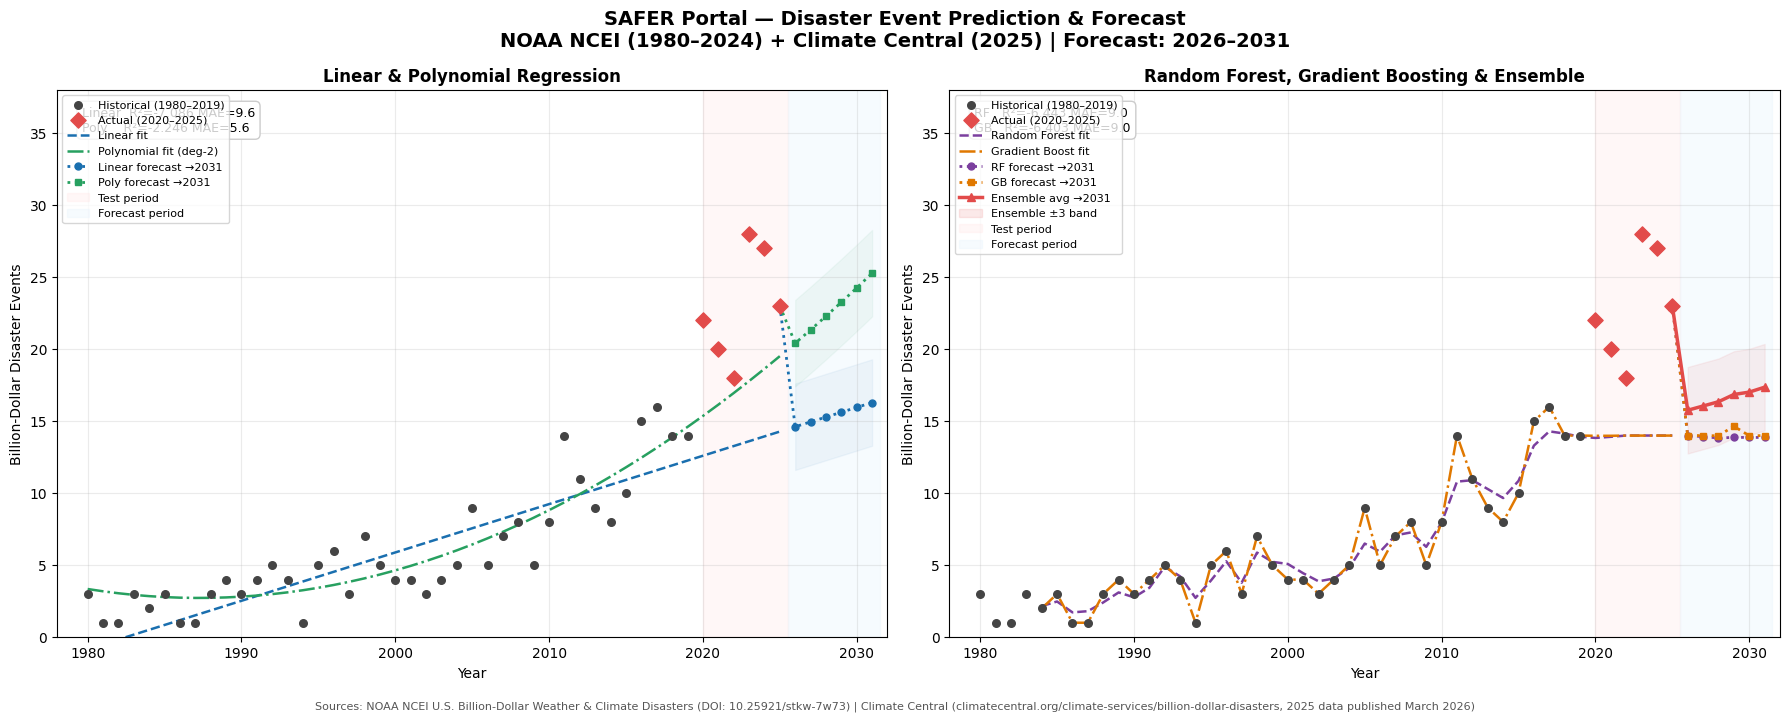

 Main prediction chart saved as disaster_prediction.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'SAFER Portal — Disaster Event Prediction & Forecast\n'
    'NOAA NCEI (1980–2024) + Climate Central (2025) | Forecast: 2026–2031',
    fontsize=14, fontweight='bold'
)

all_years  = df['Year'].values
all_events = df['Events'].values

# Years classified
hist_mask   = all_years <= TRAIN_CUTOFF
test_mask   = all_years > TRAIN_CUTOFF

# ── Panel A: Linear + Polynomial ─────────────────────────────────────────────
ax = axes[0]

ax.scatter(all_years[hist_mask], all_events[hist_mask],
           color='#444', s=30, zorder=5, label='Historical (1980–2019)')
ax.scatter(all_years[test_mask], all_events[test_mask],
           color='#E24B4A', s=60, marker='D', zorder=6, label='Actual (2020–2025)')

# Model fits on full history
fit_x = all_years.reshape(-1,1)
ax.plot(all_years, lr.predict(fit_x), color='#1a6faf', linewidth=1.8,
        linestyle='--', label='Linear fit')
ax.plot(all_years, poly.predict(fit_x), color='#27a060', linewidth=1.8,
        linestyle='-.', label='Polynomial fit (deg-2)')

# Forecasts
lr_bridge   = [all_events[-1], *future_lr]
poly_bridge = [all_events[-1], *future_poly]
yr_bridge   = np.append(2025, FORECAST_YEARS)

ax.plot(yr_bridge, lr_bridge, color='#1a6faf', linewidth=2,
        linestyle=':', marker='o', markersize=5, label='Linear forecast →2031')
ax.plot(yr_bridge, poly_bridge, color='#27a060', linewidth=2,
        linestyle=':', marker='s', markersize=5, label='Poly forecast →2031')

# Uncertainty band (±3)
ax.fill_between(FORECAST_YEARS, future_lr - 3, future_lr + 3, color='#1a6faf', alpha=0.08)
ax.fill_between(FORECAST_YEARS, future_poly - 3, future_poly + 3, color='#27a060', alpha=0.08)

# Annotations for metrics
r2_lr_t  = r2_score(y_test, y_pred_lr)
r2_p_t   = r2_score(y_test, y_pred_poly)
mae_lr_t = mean_absolute_error(y_test, y_pred_lr)
mae_p_t  = mean_absolute_error(y_test, y_pred_poly)
ax.annotate(
    f'Linear  R²={r2_lr_t:.3f} MAE={mae_lr_t:.1f}\nPoly    R²={r2_p_t:.3f} MAE={mae_p_t:.1f}',
    xy=(0.03, 0.97), xycoords='axes fraction', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ccc')
)

ax.axvspan(2020, 2025.5, color='#ffe0e0', alpha=0.25, label='Test period')
ax.axvspan(2025.5, 2031.5, color='#e8f4fd', alpha=0.35, label='Forecast period')
ax.set_title('Linear & Polynomial Regression', fontsize=12, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Billion-Dollar Disaster Events')
ax.set_xlim(1978, 2032); ax.set_ylim(0, 38)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.25)

# ── Panel B: Random Forest + Gradient Boosting + Ensemble ────────────────────
ax = axes[1]

ax.scatter(all_years[hist_mask], all_events[hist_mask],
           color='#444', s=30, zorder=5, label='Historical (1980–2019)')
ax.scatter(all_years[test_mask], all_events[test_mask],
           color='#E24B4A', s=60, marker='D', zorder=6, label='Actual (2020–2025)')

# Model fits on df_model years
model_years = df_model['Year'].values
rf_fit  = rf.predict(df_model[RF_FEATURES].values)
gb_fit  = gb.predict(df_model[RF_FEATURES].values)

ax.plot(model_years, rf_fit, color='#7B3F9E', linewidth=1.8,
        linestyle='--', label='Random Forest fit')
ax.plot(model_years, gb_fit, color='#E07800', linewidth=1.8,
        linestyle='-.', label='Gradient Boost fit')

rf_bridge  = np.append(all_events[-1], future_rf)
gb_bridge  = np.append(all_events[-1], future_gb)
ens_bridge = np.append(all_events[-1], future_ensemble)

ax.plot(yr_bridge, rf_bridge, color='#7B3F9E', linewidth=2,
        linestyle=':', marker='o', markersize=5, label='RF forecast →2031')
ax.plot(yr_bridge, gb_bridge, color='#E07800', linewidth=2,
        linestyle=':', marker='s', markersize=5, label='GB forecast →2031')
ax.plot(yr_bridge, ens_bridge, color='#E24B4A', linewidth=2.5,
        linestyle='-', marker='^', markersize=6, zorder=7, label='Ensemble avg →2031')

# Uncertainty band on ensemble ±3
ax.fill_between(FORECAST_YEARS, future_ensemble - 3, future_ensemble + 3,
                color='#E24B4A', alpha=0.12, label='Ensemble ±3 band')

r2_rf_t  = r2_score(y_test, y_pred_rf)
r2_gb_t  = r2_score(y_test, y_pred_gb)
mae_rf_t = mean_absolute_error(y_test, y_pred_rf)
mae_gb_t = mean_absolute_error(y_test, y_pred_gb)
ax.annotate(
    f'RF   R²={r2_rf_t:.3f} MAE={mae_rf_t:.1f}\nGB   R²={r2_gb_t:.3f} MAE={mae_gb_t:.1f}',
    xy=(0.03, 0.97), xycoords='axes fraction', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ccc')
)

ax.axvspan(2020, 2025.5, color='#ffe0e0', alpha=0.25, label='Test period')
ax.axvspan(2025.5, 2031.5, color='#e8f4fd', alpha=0.35, label='Forecast period')
ax.set_title('Random Forest, Gradient Boosting & Ensemble', fontsize=12, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Billion-Dollar Disaster Events')
ax.set_xlim(1978, 2032); ax.set_ylim(0, 38)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.25)

# Source footnote
fig.text(
    0.5, -0.02,
    'Sources: NOAA NCEI U.S. Billion-Dollar Weather & Climate Disasters (DOI: 10.25921/stkw-7w73) '
    '| Climate Central (climatecentral.org/climate-services/billion-dollar-disasters, 2025 data published March 2026)',
    ha='center', fontsize=8, color='#555'
)

plt.tight_layout()
plt.savefig('disaster_prediction.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(' Main prediction chart saved as disaster_prediction.png')

## Step 10 — Forecast Summary Chart (2026–2031)

Standalone chart focused purely on the forecast window — ideal for inclusion in the paper.

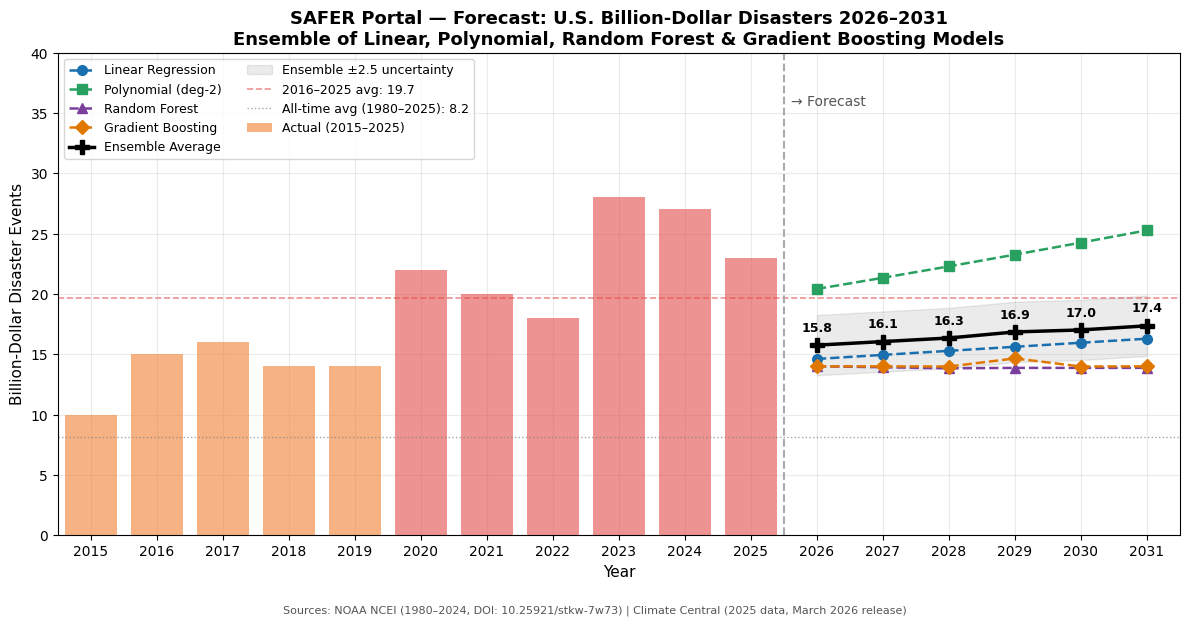

 Forecast chart saved as forecast_2026_2031.png


In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title(
    'SAFER Portal — Forecast: U.S. Billion-Dollar Disasters 2026–2031\n'
    'Ensemble of Linear, Polynomial, Random Forest & Gradient Boosting Models',
    fontsize=13, fontweight='bold'
)

# Background: actual recent years for context
recent_years  = df[df.Year >= 2015]['Year'].values
recent_events = df[df.Year >= 2015]['Events'].values

ax.bar(recent_years, recent_events,
       color=['#E24B4A' if y >= 2020 else '#F08030' for y in recent_years],
       alpha=0.6, label='Actual (2015–2025)', zorder=2)

# Individual model forecasts
ax.plot(FORECAST_YEARS, future_lr,   'o--', color='#1a6faf', lw=1.8, ms=7, label='Linear Regression')
ax.plot(FORECAST_YEARS, future_poly, 's--', color='#27a060', lw=1.8, ms=7, label='Polynomial (deg-2)')
ax.plot(FORECAST_YEARS, future_rf,   '^--', color='#7B3F9E', lw=1.8, ms=7, label='Random Forest')
ax.plot(FORECAST_YEARS, future_gb,   'D--', color='#E07800', lw=1.8, ms=7, label='Gradient Boosting')

# Ensemble with band
ax.plot(FORECAST_YEARS, future_ensemble, 'P-', color='black', lw=2.5, ms=10,
        zorder=6, label='Ensemble Average')
ax.fill_between(FORECAST_YEARS, future_ensemble - 2.5, future_ensemble + 2.5,
                color='black', alpha=0.08, label='Ensemble ±2.5 uncertainty')

# Annotate ensemble values
for yr, val in zip(FORECAST_YEARS, future_ensemble):
    ax.annotate(f'{val:.1f}', xy=(yr, val), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9,
                fontweight='bold', color='black')

# Reference lines
ax.axhline(df[df.Year >= 2016].Events.mean(), color='#E24B4A', lw=1.2, ls='--', alpha=0.6,
           label=f'2016–2025 avg: {df[df.Year>=2016].Events.mean():.1f}')
ax.axhline(df.Events.mean(), color='gray', lw=1, ls=':', alpha=0.7,
           label=f'All-time avg (1980–2025): {df.Events.mean():.1f}')

ax.axvline(2025.5, color='#aaa', lw=1.5, ls='--')
ax.text(2025.6, 36.5, '→ Forecast', fontsize=10, color='#555', va='top')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Billion-Dollar Disaster Events', fontsize=11)
ax.set_xlim(2014.5, 2031.5)
ax.set_ylim(0, 40)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(True, alpha=0.25)

fig.text(
    0.5, -0.03,
    'Sources: NOAA NCEI (1980–2024, DOI: 10.25921/stkw-7w73) | Climate Central (2025 data, March 2026 release)',
    ha='center', fontsize=8, color='#555'
)

plt.tight_layout()
plt.savefig('forecast_2026_2031.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(' Forecast chart saved as forecast_2026_2031.png')

## Step 11 — Feature Importance (Random Forest & Gradient Boosting)

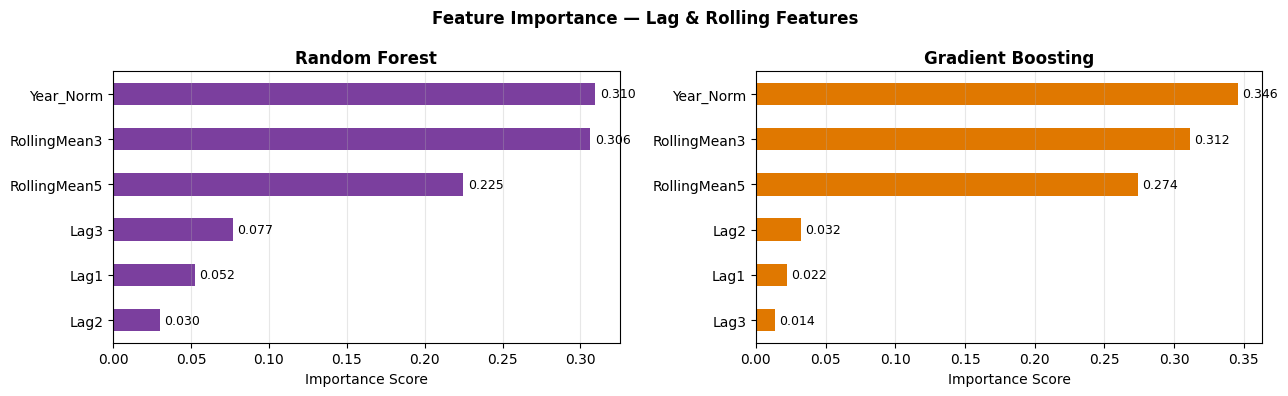

Feature importance chart saved as feature_importance_v2.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Feature Importance — Lag & Rolling Features', fontweight='bold')

for ax, model, name, palette in zip(
    axes,
    [rf, gb],
    ['Random Forest', 'Gradient Boosting'],
    [['#7B3F9E']*6, ['#E07800']*6]
):
    importances = pd.Series(model.feature_importances_, index=RF_FEATURES).sort_values()
    importances.plot.barh(ax=ax, color=palette)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(importances):
        ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved as feature_importance_v2.png')

## Step 12 — Final Model Comparison & Results Summary

In [24]:
print('=' * 70)
print('  SAFER PORTAL — DISASTER PREDICTION MODEL v2 | RESULTS SUMMARY')
print('=' * 70)

print('\n📊 MODEL PERFORMANCE (Test Set: 2020–2025)\n')
print(results_test.to_string(index=False))

print('\n\n📅 FORECAST: ANNUAL BILLION-DOLLAR DISASTERS (2026–2031)\n')
forecast_df = pd.DataFrame({
    'Year': FORECAST_YEARS,
    'Linear Reg': future_lr.round(1),
    'Polynomial': future_poly.round(1),
    'Rand. Forest': future_rf.round(1),
    'Grad. Boost': future_gb.round(1),
    'ENSEMBLE': future_ensemble.round(1)
})
print(forecast_df.to_string(index=False))

print('\n\n KEY FINDINGS')
print(f'   • Trend since 1980     : +{lr.coef_[0]:.2f} events/year (linear slope)')
print(f'   • 1980s annual average : {df[df.Year<1990].Events.mean():.1f} events/yr')
print(f'   • 2020s annual average : {df[df.Year>=2020].Events.mean():.1f} events/yr (so far)')
print(f'   • Ensemble 2031 pred.  : {future_ensemble[-1]:.1f} events/yr')
print(f'   • Dataset now spans 46 years (1980–2025), 426 total events')
print(f'   • 2025 data: Climate Central (steward since July 2025, final 2025 count published Mar 2026)')

print('\n OUTPUT FILES')
for f in ['eda_chart_v2.png','disaster_prediction_v2.png',
          'forecast_2026_2031.png','feature_importance_v2.png']:
    print(f'    {f}')

print('\n CITATIONS')
print('   [1] NOAA NCEI. U.S. Billion-Dollar Weather and Climate Disasters (2025).')
print('       DOI: 10.25921/stkw-7w73. ncei.noaa.gov/access/billions/')
print('   [2] Climate Central. U.S. Billion-Dollar Weather and Climate Disasters.')
print('       2025 annual data (23 events). Published March 2026.')
print('       climatecentral.org/climate-services/billion-dollar-disasters')
print('=' * 70)

  SAFER PORTAL — DISASTER PREDICTION MODEL v2 | RESULTS SUMMARY

📊 MODEL PERFORMANCE (Test Set: 2020–2025)

             Model     R²  MAE  RMSE  R² (train)
 Linear Regression -7.086 9.56 10.12       0.722
Polynomial (deg-2) -2.246 5.60  6.41       0.798
     Random Forest -6.443 9.04  9.71       0.930
 Gradient Boosting -6.403 9.01  9.68       1.000


📅 FORECAST: ANNUAL BILLION-DOLLAR DISASTERS (2026–2031)

 Year  Linear Reg  Polynomial  Rand. Forest  Grad. Boost  ENSEMBLE
 2026        14.6        20.4          14.0         14.0      15.8
 2027        14.9        21.3          13.9         14.0      16.1
 2028        15.3        22.3          13.8         14.0      16.3
 2029        15.6        23.3          13.9         14.7      16.9
 2030        16.0        24.3          13.9         14.0      17.0
 2031        16.3        25.3          13.9         14.0      17.4


 KEY FINDINGS
   • Trend since 1980     : +0.34 events/year (linear slope)
   • 1980s annual average : 2.2 events/yr
